In [1]:
# make sure you installed the mnist1d package

%load_ext autoreload
%autoreload 2
import torch
import import_ipynb
from a02_functions import SimpleCNN, SimpleMLP, train_model
from a02_helper import (
    plot_templates,
    get_raw_data,
    count_model_params,
    shuffle_pixels,
    plot_example,
    nextplot,
)

# Task 2: MNIST-1D
### Dataset

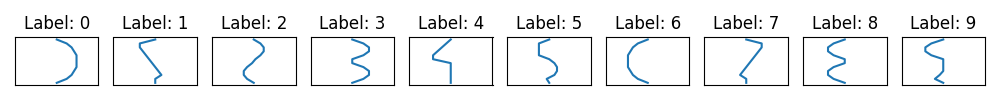

In [2]:
# Those are the templates that the examples in the dataset are based on.
nextplot()
plot_templates()

In [3]:
data = get_raw_data()

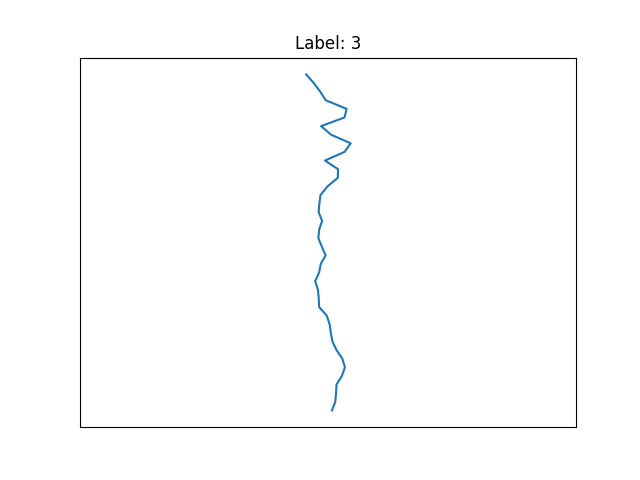

In [4]:
idx = 8
x, y, t = data["x"][idx], data["y"][idx], data["t"]
nextplot()
plot_example(x, y, t)

### Model

Verify your model's implementation by running the following test cases.

In [5]:
# 2b
torch.manual_seed(0)
cnn = SimpleCNN()
x_unbatched = torch.ones(40)
x_batched = x_unbatched.view(1, -1)
with torch.no_grad():  # these should give no error
    y_batched = cnn(x_batched)
    y_unbatched = cnn(x_unbatched)

x_batched, x_unbatched  # these are the inputs being used

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
          1., 1., 1., 1.]]),
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 1., 1.]))

Initialize your model and verify the total number of parameters computed by
hand.

In [ ]:
# 2c
torch.manual_seed(0)
cnn = SimpleCNN(channels=5, kernel_size=3, stride=2, padding=1, linear_in=5)
print(cnn)
print(f"No. of parameters: {count_model_params(cnn)}")

SimpleCNN(
  (conv1): Conv1d(1, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv2): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv3): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (conv4): Conv1d(5, 5, kernel_size=(3,), stride=(2,), padding=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (linear): Linear(in_features=25, out_features=10, bias=True)
)
No. of parameters: 520


### Training

Train your model.

In [ ]:
results = train_model(data, cnn)

### Simple Feedforward Neural Network

Compare the results of the CNN and FNN models (after your conjecture!).

In [ ]:
torch.manual_seed(0)
fnn = SimpleMLP()
print(f"No. of parameters: {count_model_params(fnn)}")

In [ ]:
results = train_model(data, fnn)

### Shuffled Dataset

Shuffle the dataset along the spatial dimension.

In [ ]:
shuffled_dataset = shuffle_pixels(data)

In [ ]:
idx = 8
x, y, t = shuffled_dataset["x"][idx], shuffled_dataset["y"][idx], shuffled_dataset["t"]
nextplot()
plot_example(x, y, t)

In [ ]:
torch.manual_seed(0)
cnn = SimpleCNN()
results = train_model(shuffled_dataset, cnn)

In [ ]:
torch.manual_seed(0)
fnn = SimpleMLP()
results = train_model(shuffled_dataset, fnn)